In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.93 s (started: 2026-06-29 18:24:55 +02:00)


In [2]:
scarf.fetch_dataset("tenx_5K_pbmc_rnaseq", save_path="scarf_datasets")

time: 23.9 s (started: 2026-06-29 18:24:56 +02:00)


In [3]:
reader = scarf.CrH5Reader("scarf_datasets/tenx_5K_pbmc_rnaseq/data.h5")

time: 13.3 ms (started: 2026-06-29 18:25:20 +02:00)


In [4]:
reader.nCells, reader.nFeatures

(5025, 33538)

time: 1.21 ms (started: 2026-06-29 18:25:20 +02:00)


In [5]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr",
    chunk_size=(2000, 1000),
)
writer.dump(batch_size=1000)

  0%|                                                                                                         …

time: 5.28 s (started: 2026-06-29 18:25:20 +02:00)


In [6]:
ds = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr", nthreads=4, min_features_per_cell=10
)

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

time: 3.41 s (started: 2026-06-29 18:25:26 +02:00)


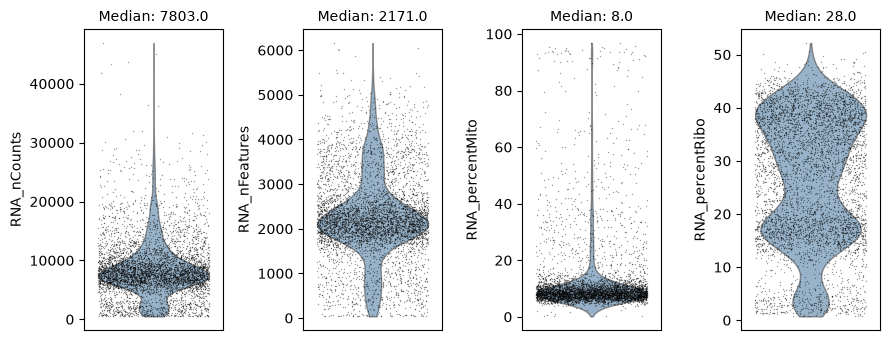

time: 1.07 s (started: 2026-06-29 18:25:29 +02:00)


In [7]:
ds.plot_cells_dists()

In [8]:
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
)

INFO: 597 cells flagged for filtering out using attribute RNA_nCounts


INFO: 461 cells flagged for filtering out using attribute RNA_nFeatures


INFO: 612 cells flagged for filtering out using attribute RNA_percentMito


time: 40.5 ms (started: 2026-06-29 18:25:30 +02:00)


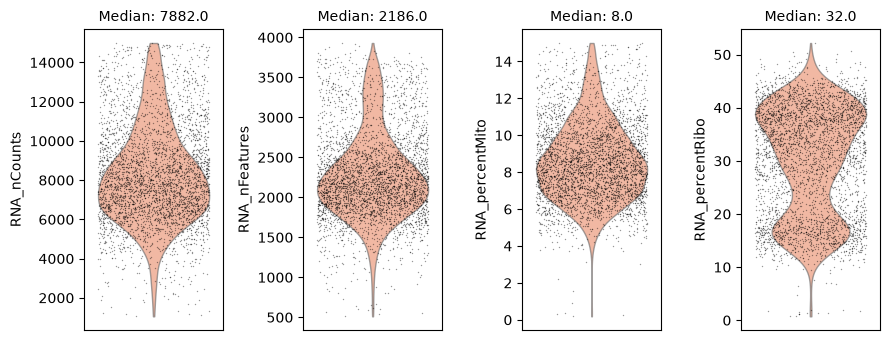

time: 649 ms (started: 2026-06-29 18:25:30 +02:00)


In [9]:
ds.plot_cells_dists(cell_key="I", color="coral")

In [10]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_percentRibo,RNA_nFeatures,RNA_nCounts
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,10.844353,16.783630,3503.0,13537.0
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,5.975687,20.034733,3381.0,12668.0
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,53.430353,2.494802,346.0,962.0
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,10.919143,28.783690,1799.0,5788.0
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,7.955407,35.750038,2887.0,13186.0


time: 93.9 ms (started: 2026-06-29 18:25:31 +02:00)


In [11]:
ds

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentRibo', 'RNA_nCounts', 
            'RNA_nFeatures', 'RNA_percentMito'
   RNA assay has 14283 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 54.5 ms (started: 2026-06-29 18:25:31 +02:00)


In [12]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts
0,False,ENSG00000243485,MIR1302-2HG,0,5025
1,False,ENSG00000237613,FAM138A,0,5025
2,False,ENSG00000186092,OR4F5,0,5025
3,True,ENSG00000238009,AL627309.1,49,4976
4,False,ENSG00000239945,AL627309.3,3,5022


time: 61.2 ms (started: 2026-06-29 18:25:31 +02:00)


In [13]:
ds.RNA.sf

1000

time: 1.72 ms (started: 2026-06-29 18:25:31 +02:00)


INFO: Calculating summary statistics


(RNA) Computing feature stats:   0%|                                                                          …

INFO: Calculating HVGs


INFO: 498 genes marked as HVGs


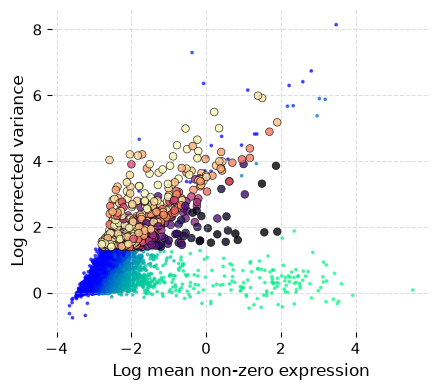

time: 6.98 s (started: 2026-06-29 18:25:31 +02:00)


In [14]:
ds.mark_hvgs(min_cells=20, top_n=500, min_mean=-3, max_mean=2, max_var=6)

In [15]:
ds.RNA.feats.head()

,I,ids,names,nCells,I__hvgs,dropOuts,stats_I_c_var__200__0.1,stats_I_normed_n,stats_I_sigmas,stats_I_nz_mean,stats_I_avg,stats_I_normed_tot
0,False,ENSG00000243485,MIR1302-2HG,0,False,5025,NaN,NaN,NaN,NaN,NaN,NaN
1,False,ENSG00000237613,FAM138A,0,False,5025,NaN,NaN,NaN,NaN,NaN,NaN
2,False,ENSG00000186092,OR4F5,0,False,5025,NaN,NaN,NaN,NaN,NaN,NaN
3,True,ENSG00000238009,AL627309.1,49,False,4976,1.5279,33.0,0.000196,0.13919,0.001166,4.593283
4,False,ENSG00000239945,AL627309.3,3,False,5022,NaN,NaN,NaN,NaN,NaN,NaN


time: 201 ms (started: 2026-06-29 18:25:38 +02:00)


In [16]:
ds.make_graph(feat_key="hvgs", k=11, dims=15, n_centroids=100)

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__hvgs/data:   0%|                                                                   …

INFO: make_graph step 1/7: normalize expression matrix finished in 1.6s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


Calculating mean and std. dev. of norm. data:   0%|                                                           …

...

INFO: ANN recall: 99.92%


INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 14.0s (7/7 steps, 14.0s in logged steps)


time: 14 s (started: 2026-06-29 18:25:38 +02:00)


In [17]:
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

Training UMAP:   0%|                                                                                          …

time: 2.54 s (started: 2026-06-29 18:25:52 +02:00)


In [18]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label="dUMAP",
)

Training UMAP:   0%|                                                                                          …

time: 6.69 s (started: 2026-06-29 18:25:55 +02:00)


In [19]:
ds.cells.head()

,I,ids,names,RNA_UMAP2,RNA_UMAP1,RNA_dUMAP2,RNA_percentRibo,RNA_dUMAP1,RNA_nFeatures,RNA_nCounts,RNA_percentMito
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,25.634027,7.201763,28.420399,16.783630,10.151650,3503.0,13537.0,10.844353
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,31.656258,-8.773814,31.849422,20.034733,-4.867432,3381.0,12668.0,5.975687
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,NaN,NaN,NaN,2.494802,NaN,346.0,962.0,53.430353
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,15.672053,-2.093645,16.925425,28.783690,-11.273490,1799.0,5788.0,10.919143
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,-8.946124,-12.210669,-8.766412,35.750038,-11.853922,2887.0,13186.0,7.955407


time: 106 ms (started: 2026-06-29 18:26:02 +02:00)


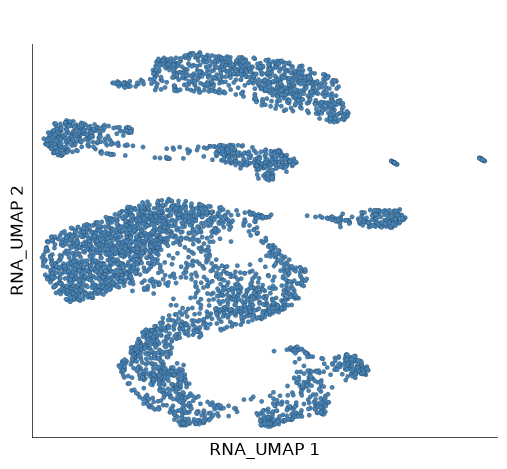

time: 184 ms (started: 2026-06-29 18:26:02 +02:00)


In [20]:
ds.plot_layout(layout_key="RNA_UMAP")

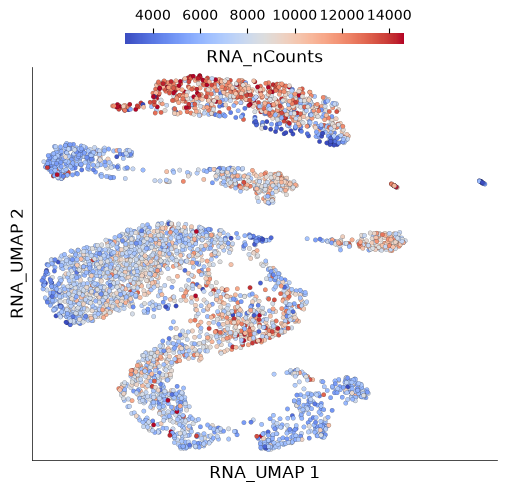

time: 377 ms (started: 2026-06-29 18:26:02 +02:00)


In [21]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_nCounts", cmap="coolwarm")

In [22]:
ds.run_tsne(alpha=10, box_h=1, early_iter=250, max_iter=500, parallel=True)

Number of vertices: 3940


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


Maximum iterations: 500


...

Iteration 450: error is 2.99241 (50 iterations in 0.142138 seconds)


Iteration 499: error is 2.99146 (50 iterations in 0.119517 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.242868 sec [22.6475%] |  Repulsive forces: 0.829516 sec [77.3525%]


time: 1.37 s (started: 2026-06-29 18:26:02 +02:00)


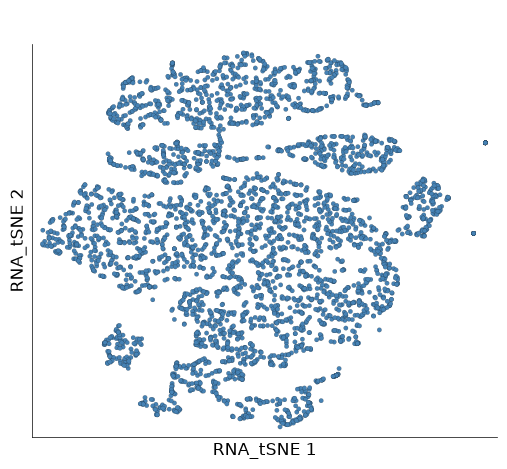

time: 176 ms (started: 2026-06-29 18:26:04 +02:00)


In [23]:
# Here we run plot_layout under exception catching because if you are not on Linux then the `run_tsne` would have failed.
try:
    ds.plot_layout(layout_key="RNA_tSNE")
except KeyError:
    print("'RNA_tSNE1' not found in MetaData")

In [24]:
# We start with Leiden clustering
ds.run_leiden_clustering(resolution=0.5)

time: 392 ms (started: 2026-06-29 18:26:04 +02:00)


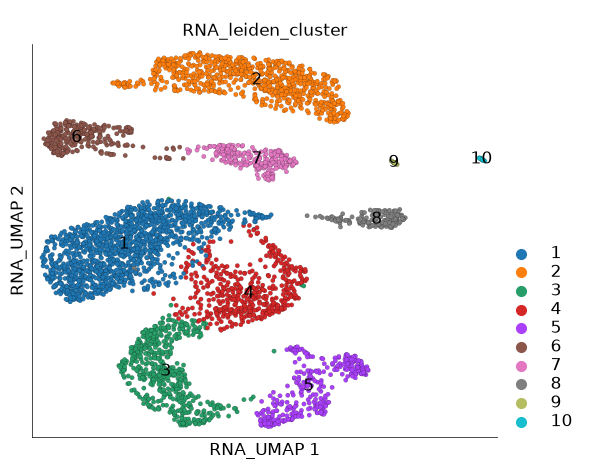

time: 310 ms (started: 2026-06-29 18:26:04 +02:00)


In [25]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_leiden_cluster")

In [26]:
ds.cells.head()

,I,ids,names,RNA_UMAP1,RNA_tSNE1,RNA_dUMAP1,RNA_dUMAP2,RNA_tSNE2,RNA_percentMito,RNA_leiden_cluster,RNA_nCounts,RNA_nFeatures,RNA_UMAP2,RNA_percentRibo
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,7.201763,-10.301678,10.151650,28.420399,19.955835,10.844353,2,13537.0,3503.0,25.634027,16.783630
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,-8.773814,9.691213,-4.867432,31.849422,25.038602,5.975687,2,12668.0,3381.0,31.656258,20.034733
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,NaN,NaN,NaN,NaN,NaN,53.430353,-1,962.0,346.0,NaN,2.494802
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,-2.093645,7.522474,-11.273490,16.925425,13.485535,10.919143,7,5788.0,1799.0,15.672053,28.783690
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,-12.210669,-17.428382,-11.853922,-8.766412,6.128800,7.955407,1,13186.0,2887.0,-8.946124,35.750038


time: 164 ms (started: 2026-06-29 18:26:05 +02:00)


In [27]:
leiden_clusters = ds.cells.to_pandas_dataframe(columns=["RNA_leiden_cluster"], key="I")
leiden_clusters.head()

,RNA_leiden_cluster
0,2
1,2
3,7
4,1
6,5


time: 41.8 ms (started: 2026-06-29 18:26:05 +02:00)


In [28]:
ds.run_clustering(n_clusters=leiden_clusters.nunique()[0])

/tmp/ipykernel_46994/1807300542.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ds.run_clustering(n_clusters=leiden_clusters.nunique()[0])


time: 351 ms (started: 2026-06-29 18:26:05 +02:00)


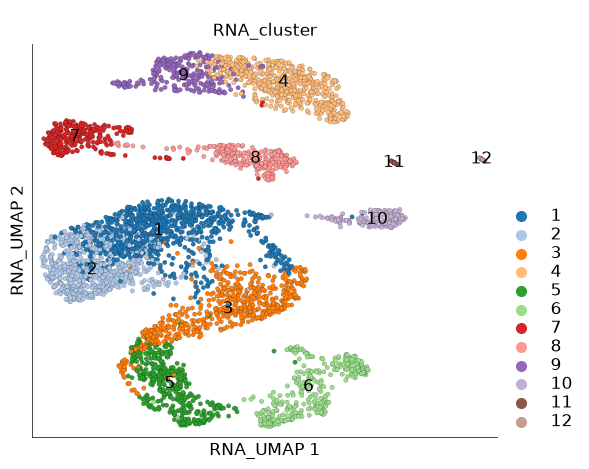

time: 308 ms (started: 2026-06-29 18:26:05 +02:00)


In [29]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_cluster")

Constructing graph from dendrogram:   0%|                                                                     …

Identifying the top node for cluster:   0%|                                                                   …

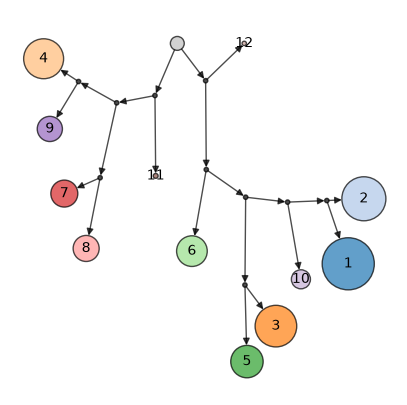

time: 687 ms (started: 2026-06-29 18:26:05 +02:00)


In [30]:
ds.plot_cluster_tree(cluster_key="RNA_cluster", width=1)

In [31]:
ds.run_marker_search(group_key="RNA_cluster", gene_batch_size=100)

Finding markers:   0%|                                                                                        …

time: 6.37 s (started: 2026-06-29 18:26:06 +02:00)


Aggregating marker values per group:   0%|                                                                    …

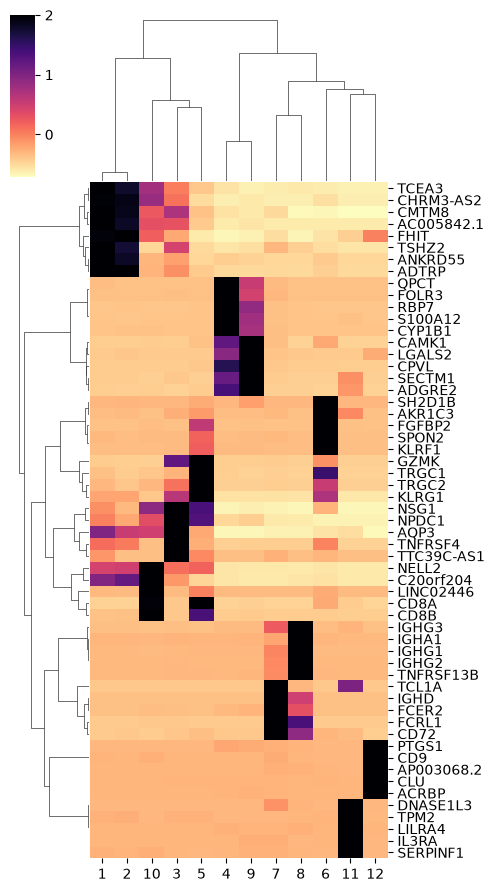

time: 1.67 s (started: 2026-06-29 18:26:13 +02:00)


In [32]:
ds.plot_marker_heatmap(group_key="RNA_cluster", topn=5, figsize=(5, 9))

In [33]:
df = ds.get_markers(
    group_key="RNA_cluster", group_id="1", min_score=-1, min_frac_exp=-1
)
df

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value
0,1,TSHZ2,29849.0,0.40857,0.08223,0.01767,0.34545,0.08738,4.65416,4.171677e-79
1,1,ANKRD55,8924.0,0.39529,0.02333,0.00401,0.15974,0.02808,5.81041,6.876416e-48
2,1,ADTRP,10307.0,0.38393,0.04075,0.00948,0.23766,0.05584,4.29811,2.141098e-55
3,1,TCEA3,487.0,0.35595,0.03329,0.00804,0.22727,0.05615,4.13832,9.997316e-51
4,1,AC005842.1,20178.0,0.34883,0.02609,0.00608,0.16494,0.04006,4.28882,4.348815e-37
...,...,...,...,...,...,...,...,...,...,...
14278,1,SYK,16290.0,0.00113,0.00054,0.06404,0.00390,0.29085,0.00838,1.921593e-62
14279,1,PDLIM1,19705.0,0.00112,0.00021,0.03954,0.00260,0.16025,0.00538,1.616561e-31
14280,1,MARCH1,8323.0,0.00110,0.00071,0.09035,0.00519,0.32240,0.00788,1.133234e-70
14281,1,ZEB2,4554.0,0.00091,0.00212,0.18227,0.01688,0.45804,0.01165,1.971131e-109


time: 296 ms (started: 2026-06-29 18:26:14 +02:00)


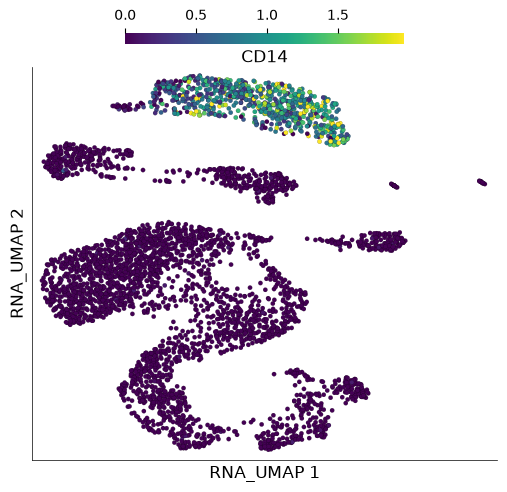

time: 353 ms (started: 2026-06-29 18:26:15 +02:00)


In [34]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="CD14")